# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [7]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [8]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

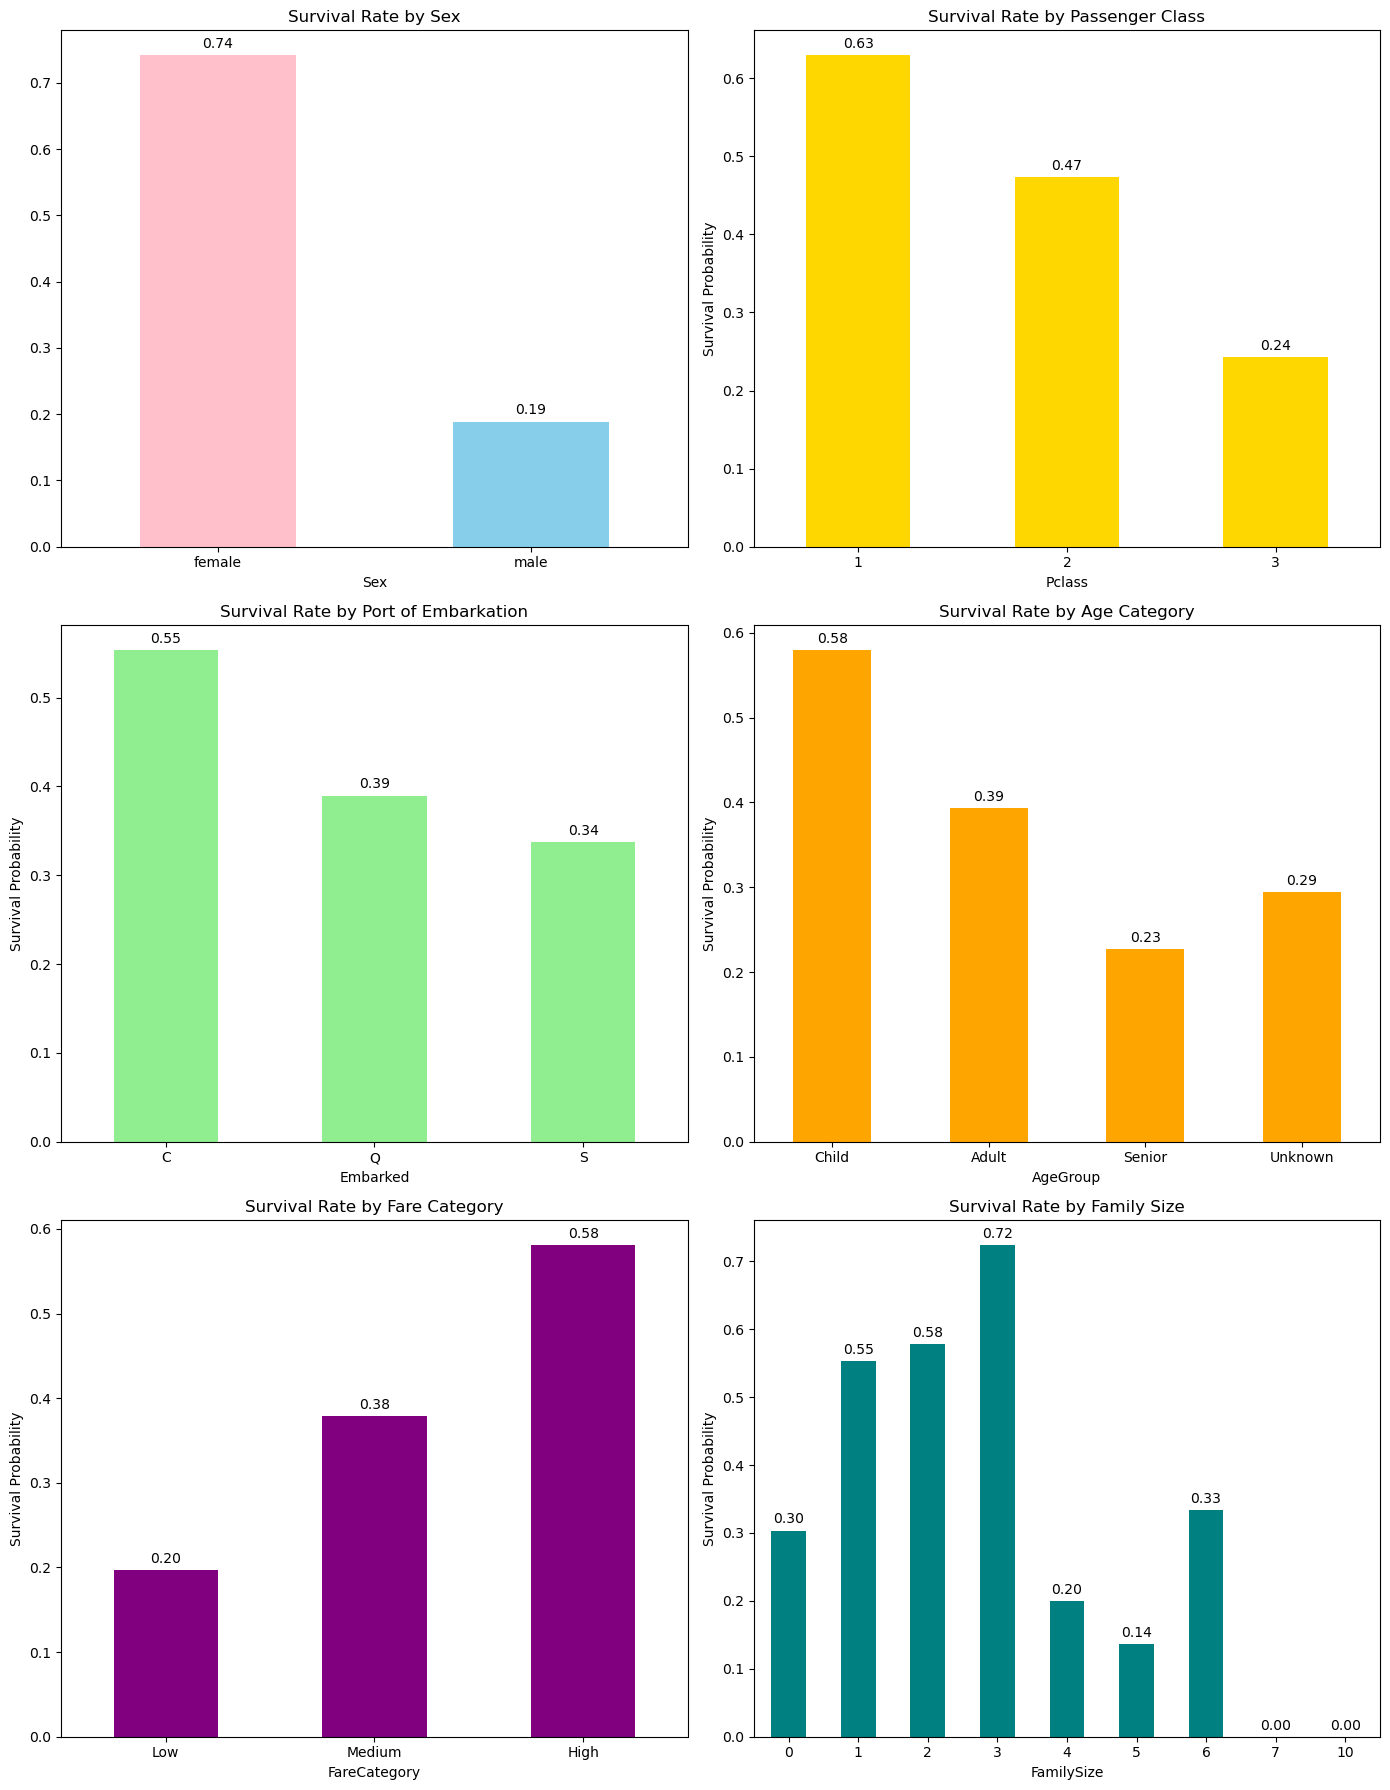

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Age Categorization Logic
df.loc[df['Age'] <= 12, 'AgeGroup'] = 'Child'
df.loc[(df['Age'] > 12) & (df['Age'] <= 60), 'AgeGroup'] = 'Adult'
df.loc[df['Age'] > 60, 'AgeGroup'] = 'Senior'
df['AgeGroup'] = df['AgeGroup'].fillna('Unknown')

# 2. Fare Categorization Logic
q25 = df['Fare'].quantile(0.25)
q75 = df['Fare'].quantile(0.75)
df.loc[df['Fare'] <= q25, 'FareCategory'] = 'Low'
df.loc[(df['Fare'] > q25) & (df['Fare'] <= q75), 'FareCategory'] = 'Medium'
df.loc[df['Fare'] > q75, 'FareCategory'] = 'High'

# 3. Travel Companions
df['FamilySize'] = df['SibSp'] + df['Parch']

# --- VISUALIZATIONS ---
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# 1. Sex
container = df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0,0], color=['pink', 'skyblue'])
axes[0,0].bar_label(axes[0,0].containers[0], fmt='%.2f', label_type='edge', padding=3)
axes[0,0].set_title('Survival Rate by Sex')

# 2. Passenger Class
container = df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0,1], color='gold')
axes[0,1].bar_label(axes[0,1].containers[0], fmt='%.2f', label_type='edge', padding=3)
axes[0,1].set_title('Survival Rate by Passenger Class')
axes[0,1].set_ylabel('Survival Probability')

# 3. Port of Departure
container = df.groupby('Embarked')['Survived'].mean().plot(kind='bar', ax=axes[1,0], color='lightgreen')
axes[1,0].bar_label(axes[1,0].containers[0], fmt='%.2f', label_type='edge', padding=3)
axes[1,0].set_title('Survival Rate by Port of Embarkation')
axes[1,0].set_ylabel('Survival Probability')

# 4. Age Groups
container = df.groupby('AgeGroup')['Survived'].mean().reindex(['Child', 'Adult', 'Senior', 'Unknown']).plot(kind='bar', ax=axes[1,1], color='orange')
axes[1,1].bar_label(axes[1,1].containers[0], fmt='%.2f', label_type='edge', padding=3)
axes[1,1].set_title('Survival Rate by Age Category')
axes[1,1].set_ylabel('Survival Probability')

# 5. Fare Categories
container = df.groupby('FareCategory')['Survived'].mean().reindex(['Low', 'Medium', 'High']).plot(kind='bar', ax=axes[2,0], color='purple')
axes[2,0].bar_label(axes[2,0].containers[0], fmt='%.2f', label_type='edge', padding=3)
axes[2,0].set_title('Survival Rate by Fare Category')
axes[2,0].set_ylabel('Survival Probability')

# 6. Travel Companions
container = df.groupby('FamilySize')['Survived'].mean().plot(kind='bar', ax=axes[2,1], color='teal')
axes[2,1].bar_label(axes[2,1].containers[0], fmt='%.2f', label_type='edge', padding=3)
axes[2,1].set_title('Survival Rate by Family Size')
axes[2,1].set_ylabel('Survival Probability')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Group Clusters
- Age: Sorted by child, adult, and senior citizen. This is based on the "women and CHILDREN first" rule for lifeboats, as well as analyzing whether or not elderly were prioritized.
- Fare: Based on 25 percentile groups for expenses.

# Data Analysis
1. Gender: Women had a 3 in 4 odds of surviving compared to men with LESS than 20%!
2. Passenger Class: Those in 1st class obviously had the most access to amenities, but socially they were also regarded as more important to preserve, leading to an overall higher percent of survivors among the wealthy.
3. Port of Embark: Those who were from Southhampton unfortunately had the lowest survival odds at roughly 3 in 10. Cherbourg passengers had better than a 50-50 chance, which seems to hint at local wealth in that region.
4. Age: Children were outright prioritized with an almost 60% survival rate-- still, an appallingly low number overall, yet a little less than triple the survival rate of seniors at 23%.
5. Fare: Those who paid high rates had better chances of survival. Interestingly enough, this is NOT a direct comparison to the classes, as different ports charged different amounts. When comparing 1st, 2nd, and 3rd class values against high, medium, and low fare rates, there is a subtle gap in data. This seems to reflect differences in personality or specific circumstances.
6. Family: Groups ranging in size from 2 to 4 had survival odds higher than 50-50, whereas large groups AND single passengers are closer to a 25% avg survival rate. Clearly the buddy system works!

In [17]:
# Look for 1st class females who boarded at Cherbourg with High fares
survivor_candidates = df[
    (df['Sex'] == 'female') & 
    (df['Pclass'] == 1) & 
    (df['Embarked'] == 'C') & 
    (df['FareCategory'] == 'High')
]
print(survivor_candidates['Name'].head())

1      Cumings, Mrs. John Bradley (Florence Briggs Th...
31        Spencer, Mrs. William Augustus (Marie Eugenie)
52              Harper, Mrs. Henry Sleeper (Myna Haxtun)
195                                 Lurette, Miss. Elise
215                              Newell, Miss. Madeleine
Name: Name, dtype: object


# Most likely to survive: Mrs. Henry Sleeper Harper (Myna Haxtun)
Myna fits the profile for a likely survivor as a higher class, high paying passenger from Cherbourg. Not only did she survive-- but her husband AND their Pekingese dog, Sun-Yat-sen, succesfully escaped onto Lifeboat #3. This couple and their dog are a prime example of how upper class had the easiest access to these emergency lifeboats.

In [18]:
# Look for 3rd class males who boarded at Southampton with Low fares
victim_candidates = df[
    (df['Sex'] == 'male') & 
    (df['Pclass'] == 3) & 
    (df['Embarked'] == 'S') & 
    (df['FareCategory'] == 'Low')
]
print(victim_candidates['Name'].head())

0          Braund, Mr. Owen Harris
29             Todoroff, Mr. Lalio
51    Nosworthy, Mr. Richard Cater
75         Moen, Mr. Sigurd Hansen
76               Staneff, Mr. Ivan
Name: Name, dtype: object


# Least likely to survive: Mr. Owen Harris Braund
Similar to Myna, Mr. Braund fits the least-likely profile as a low class low fare male from Southhampton.
A cruel twist of fate, Mr. Braund was a transfer passenger due to a coal strike, and wasn't even intende for the Titanic. He traveled with his brother Lewis.
His family heard rumors that up until the very end, he had assisted in loading passengers into the lifeboats: a true hero's death.